In [5]:
import pandas as pd
import numpy as np

In [6]:
df = pd.read_csv('../data/ko.csv')

In [7]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-02-06,38.759998,38.939999,37.919998,38.029999,27.686878,22661500
1,2014-02-07,38.169998,38.349998,37.869999,37.950001,27.628639,20389000
2,2014-02-10,38.070000,38.619999,37.840000,38.570000,28.080019,20877200
3,2014-02-11,38.669998,38.779999,38.509998,38.639999,28.130970,15361300
4,2014-02-12,38.849998,38.919998,38.400002,38.509998,28.036333,10633400


In [8]:
df.shape

(2515, 7)

In [9]:
prices = df['Close'].to_numpy()

In [10]:
commission = 1.0 # $
start_cache = 100.0 # $

In [11]:
def get_optimal_actions(prices, commission=1.0):
    n = len(prices)
    if n < 2:
        return np.full(n, 'h', dtype='U2')

    # Таблицы для хранения максимальной прибыли
    dp_cash = np.zeros(n)
    dp_stock = np.zeros(n)

    # Инициализация
    dp_cash[0] = 0
    dp_stock[0] = -prices[0] - commission

    # 1. Проход вперед (стандартный DP)
    for i in range(1, n):
        # Максимальный кэш сегодня: либо ничего не делали, либо продали
        dp_cash[i] = max(dp_cash[i-1], dp_stock[i-1] + prices[i] - commission)
        # Максимальный запас акций: либо держали старую, либо купили новую
        dp_stock[i] = max(dp_stock[i-1], dp_cash[i-1] - prices[i] - commission)

    # 2. Обратный ход для поиска ОПТИМАЛЬНЫХ и ПОТЕНЦИАЛЬНЫХ точек
    # Используем тип 'U2' для хранения строк типа 'pb', 'ps', 'b', 's'
    actions = np.full(n, 'h', dtype='U2')
    
    # Чтобы не упасть в минус, мы ориентируемся на итоговую прибыль.
    # Если в какой-то день действие дает ту же прибыль, что и оптимальное,
    # но оно не было выбрано основным путем — это потенциальная точка.

    # Сначала восстановим основной (идеальный) путь
    current_state = 0 # Заканчиваем в кэше
    for i in range(n - 1, 0, -1):
        if current_state == 0:
            if dp_cash[i] == dp_stock[i-1] + prices[i] - commission:
                actions[i] = 's'
                current_state = 1
        else:
            if dp_stock[i] == dp_cash[i-1] - prices[i] - commission:
                actions[i] = 'b'
                current_state = 0

    return actions  
 
import numpy as np

def calculate_final_balance(prices, actions, start_cash, commission=1.0):
    """
    Симуляция торговли с детальной статистикой и записью исполненных действий.
    """
    cash = float(start_cash)
    shares_held = 0
    trades_count = 0
    
    # Для статистики
    entry_value = 0      # Стоимость позиции в момент входа
    trade_profits = []   # Список результатов закрытых сделок
    
    # Массив для записи фактически исполненных сделок
    executed_actions = np.full(len(actions), 'h', dtype=object)

    for i in range(len(prices)):
        price = prices[i]
        action = actions[i]

        # BUY: Вход в позицию (только если кэш позволяет и позиция пуста)
        if action == 'b' and shares_held == 0:
            cost_per_share = price + commission
            if cash >= cost_per_share:
                num_to_buy = int(cash // cost_per_share)
                entry_value = num_to_buy * cost_per_share
                
                cash -= entry_value
                shares_held = num_to_buy
                trades_count += 1
                executed_actions[i] = 'b'

        # SELL: Выход из позиции (только если есть что продавать)
        elif action == 's' and shares_held > 0:
            exit_value = shares_held * (price - commission)
            
            # Считаем финансовый результат сделки
            trade_profit = exit_value - entry_value
            trade_profits.append(trade_profit)
            
            cash += exit_value
            shares_held = 0
            trades_count += 1
            executed_actions[i] = 's'

    # Итоговая оценка стоимости портфеля (кэш + рыночная цена остатков акций)
    final_portfolio_value = cash + (shares_held * prices[-1])
    
    # Анализ метрик
    max_profit = max(trade_profits) if trade_profits else 0
    max_loss = min(trade_profits) if trade_profits else 0
    total_net_profit = final_portfolio_value - start_cash
    win_rate = (len([p for p in trade_profits if p > 0]) / len(trade_profits) * 100) if trade_profits else 0

    # Вывод отчета
    print("-" * 40)
    print(f"{'РЕЗУЛЬТАТЫ СТРАТЕГИИ':^40}")
    print("-" * 40)
    print(f"Стартовый баланс:    {start_cash:>15.2f}")
    print(f"Конечный баланс:      {final_portfolio_value:>15.2f}")
    print(f"Чистая прибыль:      {total_net_profit:>15.2f}")
    print(f"Всего сделок:        {trades_count:>15}")
    print(f"Win Rate:            {win_rate:>14.1f}%")
    print(f"Самая прибыльная:    {max_profit:>15.2f}")
    print(f"Самая убыточная:     {max_loss:>15.2f}")
    print("-" * 40)

    return final_portfolio_value, trades_count, executed_actions

In [12]:
actions = get_optimal_actions(prices, commission)
cache, trades_count, executed_actions = calculate_final_balance(prices, actions, start_cache, commission)
print(cache, trades_count, executed_actions)

----------------------------------------
          РЕЗУЛЬТАТЫ СТРАТЕГИИ          
----------------------------------------
Стартовый баланс:             100.00
Конечный баланс:              1154.76
Чистая прибыль:              1054.76
Всего сделок:                     94
Win Rate:                     100.0%
Самая прибыльная:             111.44
Самая убыточная:                0.15
----------------------------------------
1154.7599029541016 94 ['h' 'h' 'h' ... 'h' 's' 'h']


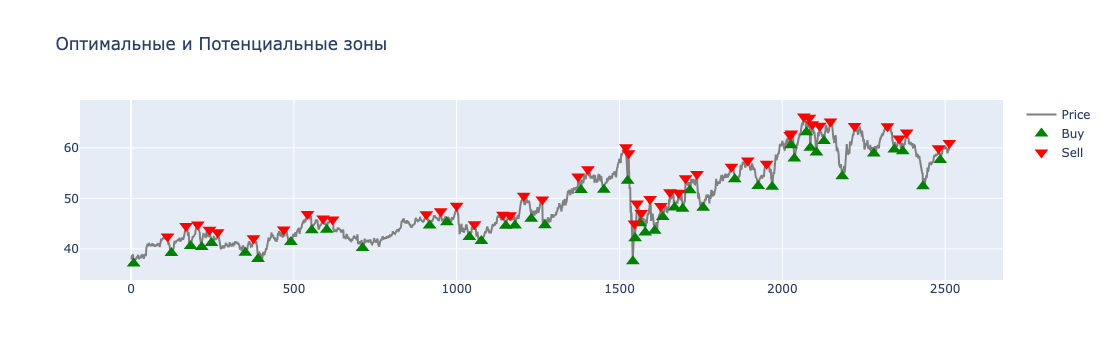

In [13]:
import plotly.graph_objects as go

days = np.arange(len(prices))
fig = go.Figure()

fig.add_trace(go.Scatter(x=days, y=prices, mode='lines', name='Price', line=dict(color='gray')))

# Списки для разных типов меток
mapping = {
    'b':  dict(color='green', symbol='triangle-up', size=12, name='Buy'),
    's':  dict(color='red', symbol='triangle-down', size=12, name='Sell'),
}

for act, style in mapping.items():
    idx = np.where(actions == act)[0]
    if len(idx) > 0:
        fig.add_trace(go.Scatter(
            x=idx, y=prices[idx], mode='markers',
            marker=dict(color=style['color'], symbol=style['symbol'], size=style['size']),
            name=style['name']
        ))

fig.update_layout(title='Оптимальные и Потенциальные зоны', hovermode='x')
fig.show()

In [14]:
def generate_continuous_feature(actions):
    n = len(actions)
    feature = np.zeros(n)
    
    # Находим индексы всех ключевых действий
    # Нам важны только 'b' и 's' (игнорируем потенциальные pb/ps для этого признака)
    key_indices = np.where((actions == 'b') | (actions == 's'))[0]
    
    if len(key_indices) < 2:
        return feature

    # Заполняем начало (до первой сделки)
    first_idx = key_indices[0]
    if actions[first_idx] == 'b':
        # Если первая сделка - покупка, то до неё мы шли от 0 к 1
        feature[:first_idx] = np.linspace(0, 1, first_idx, endpoint=False)
    else:
        # Если первая - продажа (редко), то от 1 к 0
        feature[:first_idx] = np.linspace(1, 0, first_idx, endpoint=False)

    # Заполняем основные промежутки
    for i in range(len(key_indices) - 1):
        start_idx = key_indices[i]
        end_idx = key_indices[i+1]
        length = end_idx - start_idx
        
        start_action = actions[start_idx]
        
        if start_action == 'b':
            # Отрезок [Buy -> Sell]: идем от 1 к 0
            feature[start_idx:end_idx] = np.linspace(1, 0, length, endpoint=False)
        else:
            # Отрезок [Sell -> Buy]: идем от 0 к 1
            feature[start_idx:end_idx] = np.linspace(0, 1, length, endpoint=False)

    # Заполняем хвост (после последней сделки)
    last_idx = key_indices[-1]
    last_action = actions[last_idx]
    remaining = n - last_idx
    if last_action == 'b':
        feature[last_idx:] = np.linspace(1, 0, remaining)
    else:
        feature[last_idx:] = np.linspace(0, 1, remaining)

    return feature
    
import plotly.graph_objects as go
import numpy as np

def plot_gradient_line(prices, actions, feature):
    days = np.arange(len(prices))
    
    fig = go.Figure()

    # Основная хитрость для градиентной линии:
    # Мы используем Scatter с mode='lines+markers', но делаем маркеры 
    # частью линии, задавая им тот же цвет через цветовую шкалу.
    fig.add_trace(go.Scatter(
        x=days,
        y=prices,
        mode='lines+markers',
        name='Траектория',
        line=dict(
            width=4,
            color='rgba(150,150,150,0.3)', # Тонкая серая подложка для связки
        ),
        marker=dict(
            size=6,
            color=feature,         # Привязываем цвет к признаку (0...1)
            colorscale='RdYlGn',   # Red-Yellow-Green
            showscale=True,
            colorbar=dict(
                title="Status",
                tickvals=[0, 1],
                ticktext=["Sell (0)", "Buy (1)"]
            ),
        ),
        text=[f"Признак: {f:.2f}" for f in feature],
        hoverinfo='x+y+text'
    ))

    # Добавляем крупные стрелки b и s, чтобы они выделялись на фоне линии
    buy_idx = np.where(actions == 'b')[0]
    sell_idx = np.where(actions == 's')[0]

    # Покупка
    fig.add_trace(go.Scatter(
        x=buy_idx, y=prices[buy_idx],
        mode='markers',
        name='Buy Signal',
        marker=dict(symbol='triangle-up', size=14, color='white', 
                    line=dict(width=2, color='green'))
    ))

    # Продажа
    fig.add_trace(go.Scatter(
        x=sell_idx, y=prices[sell_idx],
        mode='markers',
        name='Sell Signal',
        marker=dict(symbol='triangle-down', size=14, color='white', 
                    line=dict(width=2, color='red'))
    ))

    fig.update_layout(
        title='Непрерывный график цен с градиентом стратегии',
        xaxis_title='День',
        yaxis_title='Цена',
        template='plotly_dark',
        height=700,
        hovermode='closest'
    )

    fig.show()

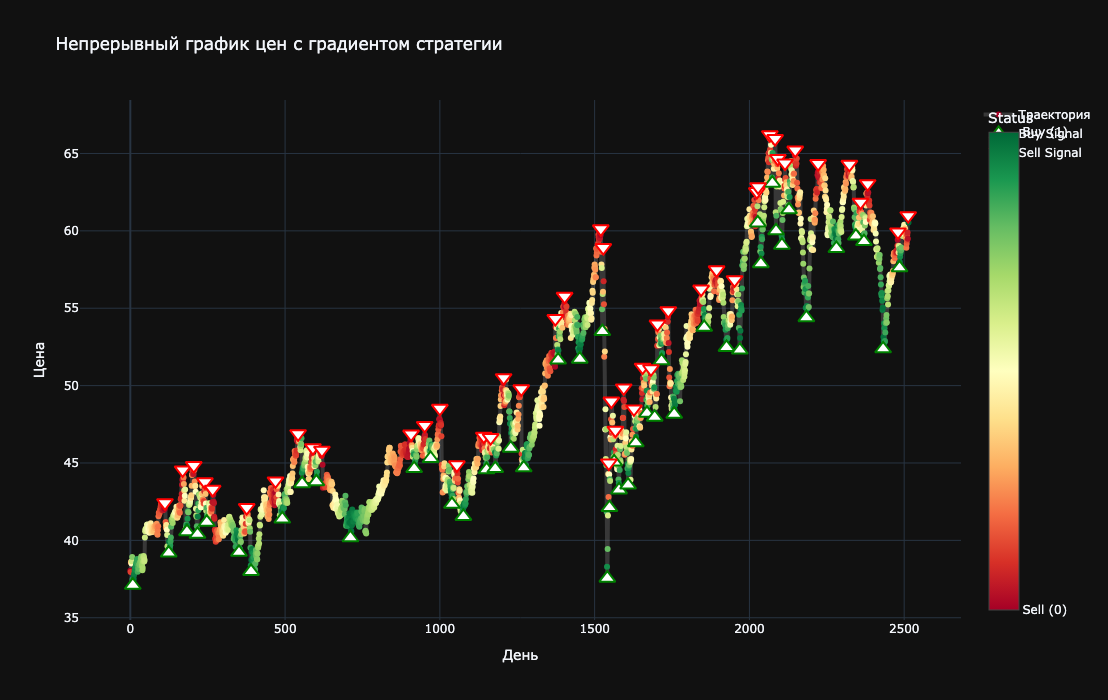

In [15]:
features = generate_continuous_feature(actions)
plot_gradient_line(prices, actions, features)

In [16]:
import numpy as np
from scipy import linalg

def predict_next_ssa(features, window_size=10, r=None):
    """
    Прогнозирует следующее значение признака методом SSA (Гусеница).
    
    :param features: Массив значений признака (0 to 1)
    :param window_size: Длина окна (L), обычно от n/10 до n/2
    :param r: Количество главных компонент для реконструкции (если None, берется 2)
    :return: Предсказанное следующее значение (float)
    """
    n = len(features)
    if n < window_size * 2:
        return features[-1]  # Недостаточно данных для анализа

    # 1. Формирование траекторной матрицы (Вложение)
    # Матрица X размера (L x K), где K = n - L + 1
    k = n - window_size + 1
    X = linalg.toeplitz(features[:window_size], features[window_size-1:])
    
    # 2. SVD разложение
    U, s, Vh = linalg.svd(X, full_matrices=False)
    
    # 3. Выбор главных компонент (Группировка)
    # r - количество компонент, отвечающих за полезный сигнал (тренд + цикл)
    if r is None:
        r = 2 
    
    # 4. Построение прогноза (L-продолжение)
    # Мы используем формулу линейного рекуррентного соотношения (LRR)
    # Вычисляем вектор коэффициентов R на основе собственных векторов
    U_truncated = U[:, :r]
    # Вектор вертикального сечения без последнего элемента
    vertical_truncated = U_truncated[:-1, :]
    # Последняя строка собственных векторов
    pi = U_truncated[-1, :]
    
    # Коэффициенты линейной регрессии для SSA
    nu = np.sum(pi**2)
    if nu >= 1.0: # Защита от неустойчивости
        nu = 0.99
        
    # Формула для получения коэффициентов предсказания
    # a = (1/(1-nu)) * sum(pi[i] * vertical_truncated[i])
    a = (1 / (1 - nu)) * np.dot(vertical_truncated, pi)
    
    # 5. Вычисление следующего значения
    # Берем последние (L-1) значений ряда и умножаем на коэффициенты a
    last_window = features[-(window_size - 1):]
    # Разворачиваем для корректного скалярного произведения (от старых к новым)
    prediction = np.dot(a, last_window)
    
    # Ограничиваем результат диапазоном (0, 1), так как это логика нашего признака
    return np.clip(prediction, 0, 1)


In [17]:
import matplotlib.pyplot as plt

# 1. Разделение на Train и Test (80/20)
# Важно: во временных рядах нельзя перемешивать данные (shuffle=False)
split_idx = int(len(features) * 0.8)
train_data = features[:split_idx]
test_data = features[split_idx:]

train_prices = prices[:split_idx]
test_prices = prices[split_idx:]

# 2. Генерация предсказаний для тестовой выборки
# Мы используем "скользящее окно": чтобы предсказать точку в тесте, 
# берем исторические данные непосредственно перед ней.
test_predictions = []
window_size = 10  # Тот же размер окна, что в функции SSA
r_components = 3  # Количество главных компонент

for i in range(len(test_data)):
    # Собираем актуальную историю: хвост трейна + то, что уже прошли в тесте
    current_history = features[:split_idx + i]
    
    # Предсказываем следующее значение
    pred = predict_next_ssa(current_history, window_size=window_size, r=r_components)
    test_predictions.append(pred)

# Превращаем в массив для удобства
test_predictions = np.array(test_predictions)

Length of Actual: 503
Length of Predicted: 503


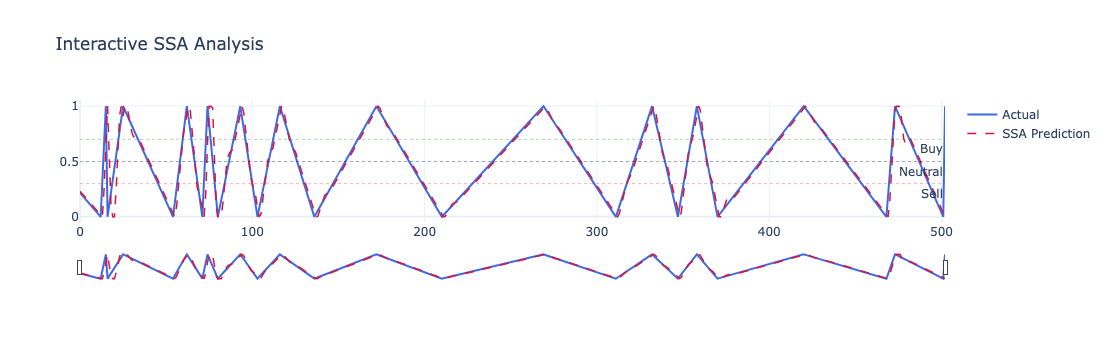

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go

# 1. Синхронизация длин
# Допустим, test_predictions — это массив прогнозов для каждой точки test_data
# Убедимся, что мы сравниваем массивы одинакового размера
min_length = min(len(test_data), len(test_predictions))

actual = test_data[:min_length]
predicted = test_predictions[:min_length]

# Проверка в консоли
print(f"Length of Actual: {len(actual)}")
print(f"Length of Predicted: {len(predicted)}")

fig = go.Figure()

# Основные линии
fig.add_trace(go.Scatter(x=np.arange(len(actual)), y=actual, name='Actual', line=dict(color='royalblue', width=2)))
fig.add_trace(go.Scatter(x=np.arange(len(predicted)), y=predicted, name='SSA Prediction', line=dict(color='crimson', width=1.5, dash='dash')))

# ИСПРАВЛЕННЫЙ БЛОК: Добавление горизонтальных уровней
thresholds = [
    {'y': 0.3, 'color': 'red', 'name': 'Sell'},
    {'y': 0.5, 'color': 'black', 'name': 'Neutral'},
    {'y': 0.7, 'color': 'green', 'name': 'Buy'}
]

for t in thresholds:
    fig.add_hline(
        y=t['y'], 
        line_width=1, 
        line_dash="dot", 
        line_color=t['color'],
        opacity=0.3, # Прозрачность задается через opacity
        annotation_text=t['name'], 
        annotation_position="bottom right"
    )

fig.update_layout(
    title='Interactive SSA Analysis',
    hovermode='x unified',
    template='plotly_white',
    xaxis=dict(rangeslider=dict(visible=True)) # Добавим слайдер снизу для удобной навигации
)

fig.show()

In [19]:
def transform_to_actions(predictions, buy_threshold=0.9, sell_threshold=0.2):
    """
    Преобразует непрерывные предсказания в дискретные действия.
    
    :param predictions: Массив предсказаний (от 0 до 1)
    :param buy_threshold: Порог для сигнала 'b' (buy)
    :param sell_threshold: Порог для сигнала 's' (sell)
    :return: Массив строк ['b', 's', 'h']
    """
    test_actions = []
    
    for val in predictions:
        if val >= buy_threshold:
            test_actions.append('b')
        elif val <= sell_threshold:
            test_actions.append('s')
        else:
            test_actions.append('h') # 'h' - hold (удержание/ожидание)
            
    return np.array(test_actions)


def transform_to_actions_by_slope(predictions):
    """
    Генерирует сигналы на основе смены направления движения:
    'b' - когда прогноз достиг пика и начал падать.
    's' - когда прогноз достиг дна и начал расти.
    """
    n = len(predictions)
    test_actions = np.full(n, 'h', dtype=object)
    
    # Начинаем с третьего элемента, чтобы можно было проверить два предыдущих
    for i in range(2, n):
        prev_2 = predictions[i-2]
        prev_1 = predictions[i-1]
        curr = predictions[i]
        
        # Логика Покупки: Пик (Был рост, стал спад)
        # ^ 
        # | \  <- сигнал здесь
        if prev_1 > prev_2 and curr < prev_1:
            test_actions[i] = 'b'
            
        # Логика Продажи: Впадина (Был спад, стал рост)
        # \   / <- сигнал здесь
        #  \_/
        elif prev_1 < prev_2 and curr > prev_1:
            test_actions[i] = 's'
            
    return test_actions

# Применяем к вашим предсказаниям
test_actions = transform_to_actions(test_predictions, buy_threshold=0.9, sell_threshold=0.1)
# test_actions = transform_to_actions_by_slope(test_predictions)

In [20]:
cache, trades_count, executed_actions = calculate_final_balance(test_prices, test_actions, start_cache, commission)
print(cache, trades_count)

----------------------------------------
          РЕЗУЛЬТАТЫ СТРАТЕГИИ          
----------------------------------------
Стартовый баланс:             100.00
Конечный баланс:               121.89
Чистая прибыль:                21.89
Всего сделок:                     24
Win Rate:                      91.7%
Самая прибыльная:               6.58
Самая убыточная:               -2.88
----------------------------------------
121.88999938964844 24


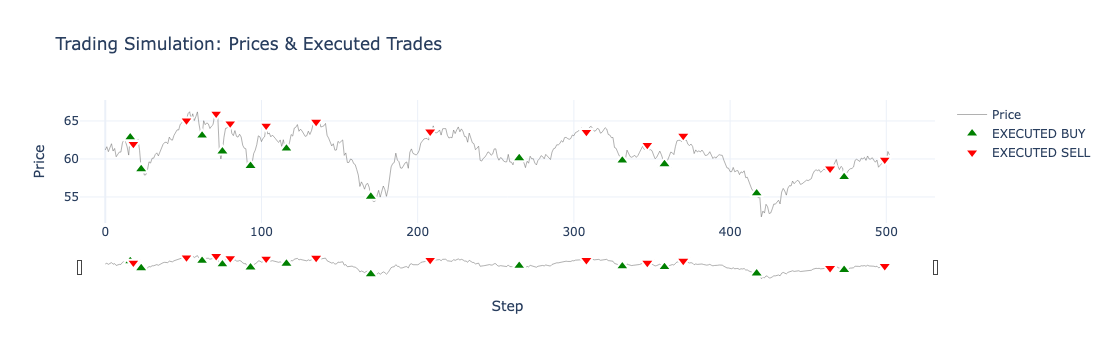

In [21]:
import plotly.graph_objects as go

# Сначала запускаем расчет
final_val, count = cache, trades_count

# Создаем график
fig = go.Figure()

# 1. Линия цены
fig.add_trace(go.Scatter(
    x=np.arange(len(test_prices)),
    y=test_prices,
    mode='lines',
    name='Price',
    line=dict(color='rgba(100, 100, 100, 0.5)', width=1)
))

# 2. Точки покупки (Buy)
buy_points = np.where(executed_actions == 'b')[0]
fig.add_trace(go.Scatter(
    x=buy_points,
    y=test_prices[buy_points],
    mode='markers',
    name='EXECUTED BUY',
    marker=dict(color='green', size=12, symbol='triangle-up', line=dict(width=2, color='white'))
))

# 3. Точки продажи (Sell)
sell_points = np.where(executed_actions == 's')[0]
fig.add_trace(go.Scatter(
    x=sell_points,
    y=test_prices[sell_points],
    mode='markers',
    name='EXECUTED SELL',
    marker=dict(color='red', size=12, symbol='triangle-down', line=dict(width=2, color='white'))
))

# Настройка интерфейса
fig.update_layout(
    title='Trading Simulation: Prices & Executed Trades',
    xaxis_title='Step',
    yaxis_title='Price',
    template='plotly_white',
    hovermode='x',
    xaxis=dict(rangeslider=dict(visible=True)) # Слайдер для зума
)

fig.show()